# Visualização do Gráfico de Condicionalidades

Este notebook demonstra como usar a função `_plot_condicionalidades_percentual` para gerar um gráfico de barras empilhadas horizontais a partir de dados de exemplo.

A função original `_plot_condicionalidades_percentual` foi adaptada para ser autônoma, removendo dependências de módulos auxiliares do projeto e incorporando a lógica de plotagem diretamente com Matplotlib.

In [1]:
2 + 3

5

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textwrap import fill
from types import SimpleNamespace

# --- Constantes e Helpers do Projeto (Mocks) ---

CONDICIONALIDADE_LABELS = {
    "1": "Seleção por critérios técnicos do cargo de diretor escolar",
    "2": "Participação (>=80%) no Sistema de Avaliação da Educação Basica - Saeb",
    "3": "Redução das desigualdades",
    "4": "Regulamentação do ICMS Educacional no estado",
    "5": "Referenciais curriculares alinhados a Base Nacional Comum Curricular",
}

AXIS_SIZE = 12
LABEL_SIZE = 10

def ensure_rawline_font_available(strict=False):
    """Mock: não faz nada."""
    pass

def get_chart_font_family():
    """Mock: retorna a família de fontes padrão."""
    return "sans-serif"

In [3]:
def _plot_condicionalidades_percentual(
    df: pd.DataFrame,
    ctx: SimpleNamespace, # Adaptado para SimpleNamespace
    level_label: str,
    col_cond: str,
    col_att: str,
    col_pct: str,
    *,
    label_width_ratio: float = 0.50,
    chart_width_ratio: float | None = None,
    label_font_size: float | None = None,
    legend_height_ratio: float = 0.18,
    show_legend: bool = True,
) -> plt.Figure | None:
    """
    Gera grafico de barras empilhadas horizontais para percentual de atendimento.

    O layout e separado em duas colunas:
    1) area exclusiva para rotulos (eixo Y)
    2) area exclusiva para barras

    Isso evita corte de rotulos longos e permite controlar a proporcao visual
    entre rotulos e grafico com `label_width_ratio` / `chart_width_ratio`.
    """

    def _resolve_width_ratios(
        label_ratio: float,
        chart_ratio: float | None,
    ) -> tuple[float, float]:
        """Resolve ratios allowing fixed fraction or weighted pair."""
        if label_ratio <= 0:
            raise ValueError("label_width_ratio deve ser maior que zero.")
        if chart_ratio is None:
            if label_ratio >= 1:
                raise ValueError(
                    "Sem chart_width_ratio, label_width_ratio deve estar no intervalo (0, 1)."
                )
            return (label_ratio, 1.0 - label_ratio)
        if chart_ratio <= 0:
            raise ValueError("chart_width_ratio deve ser maior que zero.")
        total = label_ratio + chart_ratio
        return (label_ratio / total, chart_ratio / total)

    def _wrap_width_for_labels(
        figsize: tuple[float, float],
        label_ratio: float,
        axis_text_size: float,
    ) -> int:
        """Estimate wrapping width (chars) from reserved label area."""
        fig_width_in = float(figsize[0]) if figsize and len(figsize) >= 1 else 10.0
        label_width_in = max(0.8, fig_width_in * label_ratio * 0.95)
        chars_per_inch = max(6.0, 15.0 - (axis_text_size * 0.6))
        width = int(round(label_width_in * chars_per_inch))
        # Evita quebra excessiva que causa sobreposicao visual dos rotulos.
        return max(28, min(56, width))

    def _fit_label_font_size(
        desired_size: float,
        labels: list[str],
        figsize: tuple[float, float],
        show_legend_flag: bool,
        legend_ratio: float,
    ) -> float:
        """
        Limita automaticamente o tamanho da fonte para evitar sobreposicao
        vertical entre rotulos em linhas diferentes.
        """
        if not labels:
            return desired_size
        fig_height_in = float(figsize[1]) if figsize and len(figsize) >= 2 else 5.0
        legend_h = max(0.10, legend_ratio)
        chart_fraction = 1.0 / (1.0 + legend_h) if show_legend_flag else 1.0
        outer_fraction = 0.90 if show_legend_flag else 0.92
        usable_height_in = fig_height_in * chart_fraction * outer_fraction
        row_height_in = usable_height_in / max(1, len(labels))
        max_lines = max(label.count('\n') + 1 for label in labels)
        # 1.2 aproxima line-height padrao do matplotlib.
        safe_size = (row_height_in * 72.0) / max(1.0, max_lines * 1.2)
        return max(4.0, min(desired_size, safe_size))

    if df is None or df.empty:
        return None

    required = {col_cond, col_att, col_pct}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Colunas obrigatorias ausentes para grafico: {sorted(missing)}")

    data = df.copy()
    data[col_cond] = data[col_cond].astype(str)
    data[col_att] = data[col_att].astype(str).str.lower()
    data[col_pct] = pd.to_numeric(data[col_pct], errors="coerce").fillna(0.0)

    pivot = (
        data.pivot_table(
            index=col_cond,
            columns=col_att,
            values=col_pct,
            aggfunc="sum",
            fill_value=0.0,
        )
        .reindex(columns=["true", "false", "pendente"], fill_value=0.0)
        .reset_index()
    )
    pivot["ord"] = pd.to_numeric(pivot[col_cond], errors="coerce")
    pivot = pivot.sort_values(by=["ord", col_cond]).drop(columns=["ord"])

    ensure_rawline_font_available(strict=False)
    font_family = get_chart_font_family()
    axis_text_size = AXIS_SIZE - 5
    label_text_size = float(label_font_size) if label_font_size is not None else float(axis_text_size)
    bar_label_size = LABEL_SIZE + 2

    resolved_label_ratio, resolved_chart_ratio = _resolve_width_ratios(
        label_ratio=label_width_ratio,
        chart_ratio=chart_width_ratio,
    )
    wrap_width = _wrap_width_for_labels(
        figsize=ctx.figsize,
        label_ratio=resolved_label_ratio,
        axis_text_size=label_text_size,
    )
    cond_labels = [
        fill(CONDICIONALIDADE_LABELS.get(v, f"Condicionalidade {v}"), width=wrap_width)
        for v in pivot[col_cond].tolist()
    ]
    label_text_size = _fit_label_font_size(
        desired_size=label_text_size,
        labels=cond_labels,
        figsize=ctx.figsize,
        show_legend_flag=show_legend,
        legend_ratio=legend_height_ratio,
    )
    wrap_width = _wrap_width_for_labels(
        figsize=ctx.figsize,
        label_ratio=resolved_label_ratio,
        axis_text_size=label_text_size,
    )
    pivot["cond_label"] = [
        fill(CONDICIONALIDADE_LABELS.get(v, f"Condicionalidade {v}"), width=wrap_width)
        for v in pivot[col_cond].tolist()
    ]

    if show_legend:
        fig = plt.figure(figsize=ctx.figsize)
        grid = fig.add_gridspec(
            nrows=2,
            ncols=2,
            width_ratios=[resolved_label_ratio, resolved_chart_ratio],
            height_ratios=[1.0, max(0.10, legend_height_ratio)],
            left=0.04,
            right=0.99,
            top=0.98,
            bottom=0.08,
            wspace=0.02,
            hspace=0.0,
        )
        ax_labels = fig.add_subplot(grid[0, 0])
        ax_chart = fig.add_subplot(grid[0, 1], sharey=ax_labels)
        ax_legend = fig.add_subplot(grid[1, :])
    else:
        fig = plt.figure(figsize=ctx.figsize)
        grid = fig.add_gridspec(
            nrows=1,
            ncols=2,
            width_ratios=[resolved_label_ratio, resolved_chart_ratio],
            left=0.04,
            right=0.99,
            top=0.98,
            bottom=0.06,
            wspace=0.02,
        )
        ax_labels = fig.add_subplot(grid[0, 0])
        ax_chart = fig.add_subplot(grid[0, 1], sharey=ax_labels)
        ax_legend = None

    # --- Lógica de plotagem (substitui o helper plot_barras_empilhadas) ---
    status_cols = ["true", "false", "pendente"]
    colors = {
        "true": "#048838",
        "false": "#ED1C24",
        "pendente": "#BDBDBD",
    }
    status_labels = {
        "true": "Atendido",
        "false": "Não atendido",
        "pendente": "Pendente",
    }
    
    y_positions = np.arange(len(pivot), dtype=float)
    left = np.zeros(len(pivot))
    bar_width = 0.78
    label_threshold = 8.0

    for status in status_cols:
        if status in pivot.columns:
            values = pivot[status].to_numpy()
            ax_chart.barh(
                y_positions, 
                values, 
                left=left, 
                height=bar_width, 
                label=status_labels[status], 
                color=colors[status]
            )
            
            # Adiciona rótulos nas barras
            for i, (val, l) in enumerate(zip(values, left)):
                if val >= label_threshold:
                    label_text = ctx.format_percent(val, 0)
                    ax_chart.text(l + val / 2, y_positions[i], label_text, 
                                  ha='center', va='center', color='white', 
                                  fontsize=bar_label_size)
            
            left += values
    # --- Fim da lógica de plotagem ---

    ax_chart.set_xlim(0, 100)
    ax_chart.set_xlabel("")
    ax_chart.set_xticks([])
    ax_chart.set_yticks(y_positions)
    ax_chart.set_yticklabels([])
    ax_chart.tick_params(axis="y", length=0, labelleft=False)
    ax_chart.set_facecolor("none")
    ax_labels.set_xlim(0.0, 1.0)
    ax_labels.set_xticks([])
    ax_labels.set_yticks(y_positions)
    ax_labels.set_yticklabels([])
    ax_labels.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False)
    ax_labels.grid(False)
    ax_labels.xaxis.grid(False)
    ax_labels.yaxis.grid(False)
    for spine in ax_labels.spines.values():
        spine.set_visible(False)
    ax_labels.set_facecolor("none")
    for y, label in zip(y_positions, pivot["cond_label"].tolist()):
        ax_labels.text(
            1.0,
            y,
            label,
            ha="right",
            va="center",
            fontsize=label_text_size,
            fontfamily=font_family,
            clip_on=False,
        )

    if ax_legend is not None:
        ax_legend.axis("off")
        handles, labels = ax_chart.get_legend_handles_labels()
        legend = ax_legend.legend(
            handles,
            labels,
            loc="center",
            ncol=3,
            frameon=False,
            fontsize=axis_text_size,
        )
        for text in legend.get_texts():
            text.set_fontfamily(font_family)

    return fig

In [4]:
# --- Criação dos Dados de Exemplo ---

sample_data = {
    "condicionalidade": ["1", "1", "1", "2", "2", "2", "3", "3", "3", "4", "4", "4", "5", "5", "5"],
    "atendimento": ["true", "false", "pendente"] * 5,
    "percentual": [
        # Cond 1: 50 + 30 + 20 = 100
        50, 30, 20,
        # Cond 2: 85 + 5 + 10 = 100
        85, 5, 10,
        # Cond 3: 10 + 70 + 20 = 100
        10, 70, 20,
        # Cond 4: 100 + 0 + 0 = 100
        100, 0, 0,
        # Cond 5: 0 + 25 + 75 = 100
        0, 25, 75
    ]
}
df_exemplo = pd.DataFrame(sample_data)

print("Dados de Exemplo:")
df_exemplo

Dados de Exemplo:


,condicionalidade,atendimento,percentual
0,1,true,50
1,1,false,30
2,1,pendente,20
3,2,true,85
4,2,false,5
5,2,pendente,10
6,3,true,10
7,3,false,70
8,3,pendente,20
9,4,true,100


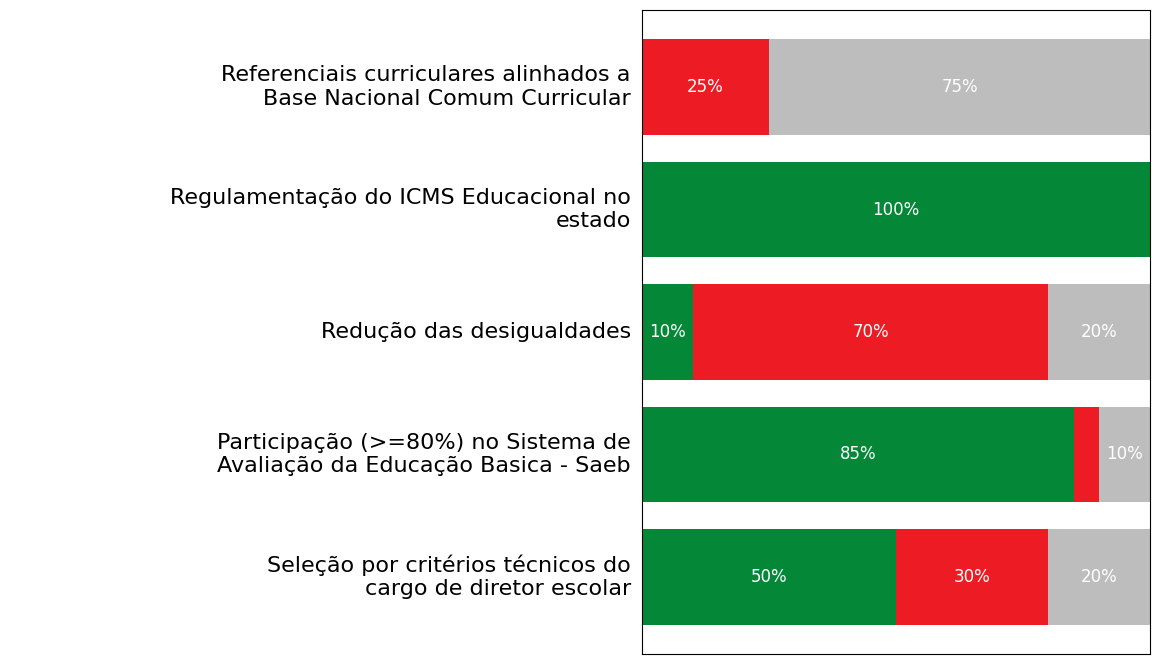

In [14]:
# --- Configuração do Contexto e Execução ---

# Mock do ChartContext
ctx_exemplo = SimpleNamespace(
    figsize=(12, 7), # Aumentado para melhor visualização
    dpi=100,
    format_percent=lambda v, p: f"{v:.{p}f}%"
)

# Chamada da função para gerar o gráfico
figura = _plot_condicionalidades_percentual(
    df=df_exemplo,
    ctx=ctx_exemplo,
    level_label="Exemplo",
    col_cond="condicionalidade",
    col_att="atendimento",
    col_pct="percentual",
    label_width_ratio=0.55, # Ajustado para labels mais longos
    label_font_size=16.0,
    show_legend=False
)

# Exibição do gráfico
if figura:
    plt.show()
else:
    print("Não foi possível gerar o gráfico.")